In [1]:
import numpy as np 
from netCDF4 import Dataset
import os
import tensorflow as tf
import argparse
import pandas as pd
from tensorflow import keras

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import time
import matplotlib
import matplotlib.ticker as mticker
import warnings

%matplotlib inline



2025-07-10 12:09:47.756805: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX512_VNNI AVX512_BF16
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-10 12:09:48.233194: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# HOME = "/scistor/ivm/the410/"

HOME = "/home/thappe/" #snellius

In [3]:
os.chdir(f"{HOME}/HeaT")
#sys.path.append(os.path.expanduser('/home/thappe/HeaT'))

from HeaT.TFrecord_utils_ERA_v2 import *
from HeaT.reconstruction import *
from HeaT.clustering import Clustering


## Get ERA5 heatwave means and cluster allocations



In [168]:
data_path = "/home/thappe/data/VAE_MODEL"

In [169]:
t2m_thermo_clustered = Clustering(t2m_name = "t2m_minus_thermo", 
                                  VAE_model = (128, f"{data_path}/VAE3D_3D_noRSDS_5d_TRANSFER_L128_B0.01_F4_AUGMENTED_final.h5"),
                                  data_path="/home/thappe/data/VAE_MODEL", 
                                  standardization_method="standardization_cut",
                                  cluster_model_name="GMM", 
                                  cluster_type="fit",
                                  cluster_k = 4)

heatwave_means = t2m_thermo_clustered.heatwave_means
heatwave_clusters = t2m_thermo_clustered.y_pred
heatwave_clusters_probs = t2m_thermo_clustered.y_pred_proba
heatwave_dates = t2m_thermo_clustered.heatwave_dates

loading GMM


2025-07-10 15:04:39.331718: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:267] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-07-10 15:04:39.334168: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (tcn1183.local.snellius.surf.nl): /proc/driver/nvidia/version does not exist
2025-07-10 15:04:39.354037: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX512_VNNI AVX512_BF16
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [8]:
heatwave_means.shape

(739, 128)

In [9]:
heatwave_dates.shape

(739,)

In [8]:
ls /home/thappe/data/heatwaves

ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.csv
ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.nc
ERA5_2020_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.csv
ERA5_2020_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.nc
ERA5_land_sea_mask_WestEU_lentisgrid.nc
gdbscan_on_snellius/
gridarea_westEU_lentisgrid.nc
T2M_dynamic_ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.csv
T2M_dynamic_ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.nc
T2M_minus_thermo_ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.csv
T2M_minus_thermo_ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.nc


In [9]:
# heatwave_file = "ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.csv"
# t2m = "t2m"

# heatwave_file = "T2M_dynamic_ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.csv"
# t2m = "t2m_dynamic"

heatwave_file = "T2M_minus_thermo_ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.csv"
t2m = "t2m_minus_thermo"

In [22]:
data = pd.read_csv(f'/home/thappe/data/heatwaves/{heatwave_file}', 
                             header=0)
data

,year,Heatwave number (clusterID),day 0 (index),start date,end date,duration in days,maximum spatial extent in km2,cumulative_heat_index (C*km2),peak intensity (max(sum(temp) per day)),peak intensity day,average daily temp (mean(mean C per day)),average daily temp (mean of all temperatures),"spatial range (lon_min, lon_max, lat_min, lat_max)",midpoint tracker
0,1940,-1 (NOISE),,,,,,,,,,,,
1,1940,0,32,1940-08-02,1940-08-01,5,12454,890588.35,483.93,1940-08-03,17.83,17.86,"(np.float64(-9.84375), np.float64(-4.21875), n...","(np.float64(-7.03125), np.float64(53.333187039..."
2,1940,1,33,1940-08-03,1940-08-05,3,7738,398118.4,328.22,1940-08-04,21.96,22.01,"(np.float64(-4.21875), np.float64(0.0), np.flo...","(np.float64(-2.8125), np.float64(48.0700542176..."
3,1940,2,34,1940-08-04,1940-08-06,3,9529,444500.13,408.46,1940-08-04,20.18,20.23,"(np.float64(-3.515625), np.float64(0.703125), ...","(np.float64(-1.40625), np.float64(51.929685516..."
4,1940,3,36,1940-08-06,1940-08-09,4,14032,1072885.77,647.74,1940-08-08,26.79,26.98,"(np.float64(-7.734375), np.float64(-4.921875),...","(np.float64(-7.03125), np.float64(41.052536759..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1000,2023,7,40,2023-08-10,2023-08-12,3,6240,395160.03,264.16,2023-08-11,26.44,26.38,"(np.float64(-5.625), np.float64(-3.515625), np...","(np.float64(-4.921875), np.float64(36.14027136..."
1001,2023,8,43,2023-08-13,2023-08-16,4,31652,1022189.99,764.9,2023-08-14,12.7,12.95,"(np.float64(7.03125), np.float64(14.765625), n...","(np.float64(12.3046875), np.float64(48.0700541..."
1002,2023,9,47,2023-08-17,2023-08-28,12,257403,33795815.93,8707.19,2023-08-21,19.13,18.41,"(np.float64(-9.84375), np.float64(14.765625), ...","(np.float64(0.703125), np.float64(43.719193046..."
1003,2023,10,48,2023-08-18,2023-08-17,3,4568,174790.65,145.55,2023-08-19,15.33,15.26,"(np.float64(-6.328125), np.float64(-3.515625),...","(np.float64(-4.921875), np.float64(53.68406238..."


In [163]:

durations = []
cumheats  = []
peak_intensity = []
average_temp = []
years = []
cluster_nrs ={}

prev_start_date = "init"
year_prev = 1940
cluster_list = []
for i, year in enumerate(data['year']):
    if data["duration in days"][i] == ' ':
        continue
    else: 
        current_start_date = data["start date"][i]
        if current_start_date == prev_start_date:
#             print("duplicate", prev_start_date, current_start_date )
            continue
        else:
            
            durations.append(int(data["duration in days"][i]))
            cumheats.append(float(data["cumulative_heat_index (C*km2)"][i]))
            peak_intensity.append(float(data["peak intensity (max(sum(temp) per day))"][i]))
            average_temp.append(float(data["average daily temp (mean of all temperatures)"][i]))      
            years.append(year)
            
        
            if int(year) == year_prev:
                cluster_list.append(int(data['Heatwave number (clusterID)'][i]))
            else:
                cluster_nrs[int(year_prev)]=(cluster_list)
                cluster_list = [int(data['Heatwave number (clusterID)'][i])] #restart count and add this year 
                year_prev = int(year)
                
            
            
        prev_start_date = current_start_date

#also append the last year to the dict
cluster_nrs[int(year_prev)]=(cluster_list)
    

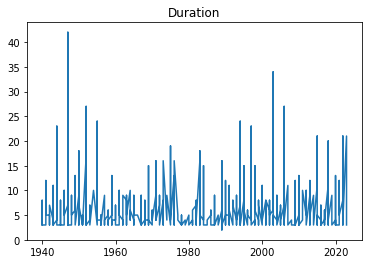

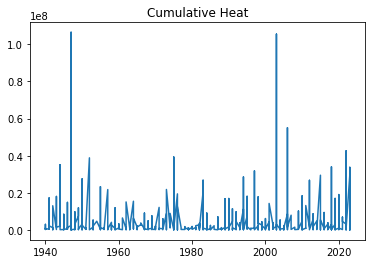

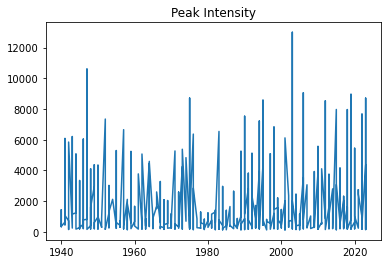

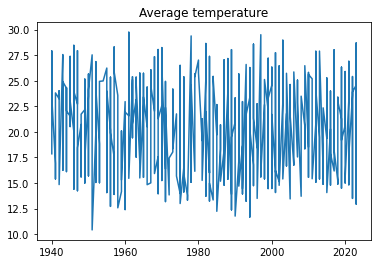

<Figure size 432x288 with 0 Axes>

In [164]:
plt.plot(years, durations)
plt.title("Duration")
plt.show()
plt.clf()

plt.plot(years, cumheats)
plt.title("Cumulative Heat")
plt.show()
plt.clf()

plt.plot(years, peak_intensity)
plt.title("Peak Intensity")
plt.show()
plt.clf()

plt.plot(years, average_temp)
plt.title("Average temperature")
plt.show()
plt.clf()

In [145]:
len(durations)

739

#### what if I use the normal t2m data to calculate these indices, instead of the dynamical temp?

In [44]:
import xarray as xr

In [94]:
clusters = xr.open_dataset(
    f"/home/thappe/data/heatwaves/T2M_minus_thermo_ERA5_1940_2023_lentis_EU_heatwave_clusters_p90mp21_cdopercentile.nc")["clusterID"]
temperature = xr.open_dataset('/home/thappe/data/ERA5/1940-2023_T2M_westEU_June23-JA-Sept7_LENTISGRID.nc')['t2m']
temperature = temperature.sel(time=temperature.time.dt.month.isin([7,8]))

In [64]:
clusters #for each year I can use the cluster numbers to access the gridpoint info

<xarray.DataArray 'clusterID' (year: 84, day: 62, lat: 28, lon: 36)>
[5249664 values with dtype=float64]
Dimensions without coordinates: year, day, lat, lon
Attributes:
    units:      cluster_ID
    long_name:  clusterID

In [165]:
years = []
means = []
clms = []
mxs = []

count = 0
for i, (year, cluster_ids) in enumerate(cluster_nrs.items()):
#     print(i, year, cluster_ids)
    for cluster_id in cluster_ids:
        count += 1
        indices = np.where(clusters[i]==[cluster_id])
        temp_year = temperature.sel(time=temperature.time.dt.year==year).values
        temp_vlues = temp_year[indices]- 273.15
        ## now calculate some statistics 
        mean, cml, mx = np.mean(temp_vlues), np.sum(temp_vlues), np.max(temp_vlues)
        years.append(year)
        means.append(mean)
        clms.append(cml)
        mxs.append(mx)


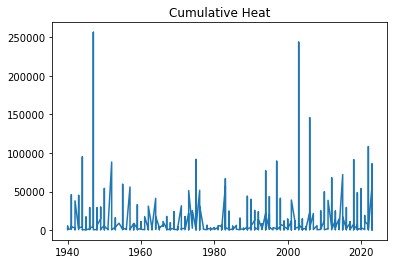

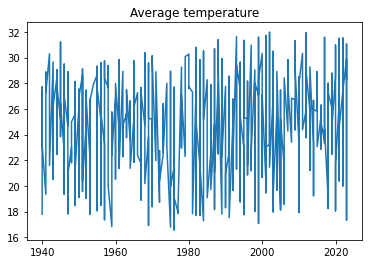

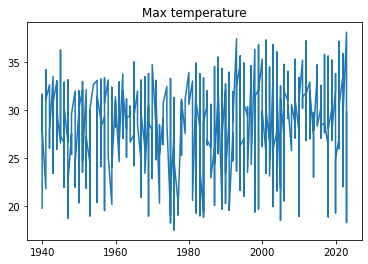

<Figure size 432x288 with 0 Axes>

In [166]:
plt.plot(years, clms)
plt.title("Cumulative Heat")
plt.show()
plt.clf()

plt.plot(years, means)
plt.title("Average temperature")
plt.show()
plt.clf()


plt.plot(years, mxs)
plt.title("Max temperature")
plt.show()
plt.clf()

## now combine with clusters and tsne

In [171]:
heatwave_clusters.shape

(739,)

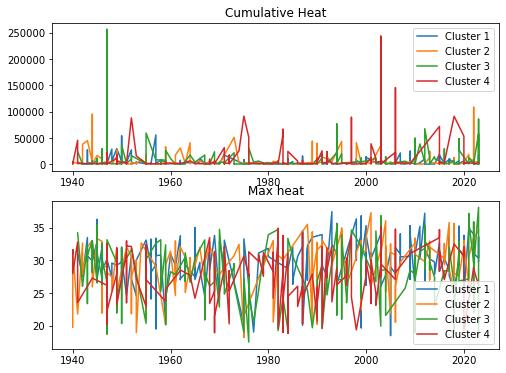

In [180]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6))

for cluster_nr in np.unique(heatwave_clusters):
    ind = np.where(heatwave_clusters==cluster_nr)[0]
    clms_ = np.array(clms)[ind]
    mxs_ = np.array(mxs)[ind]
    years_ = np.array(years)[ind]
    axes[0].plot(years_, clms_, label=f"Cluster {cluster_nr+1}")
    axes[0].set_title("Cumulative Heat")
    axes[0].legend()
    axes[1].plot(years_, mxs_, label=f"Cluster {cluster_nr+1}")
    axes[1].set_title("Max heat")
    axes[1].legend()

1 [311, 548, 82, 217, 254, 216, 81, 283, 516, 253]
2 [228, 643, 212, 202, 203, 594, 439, 133, 486, 125]
3 [140, 7, 66, 621, 555, 571, 494, 476, 398, 229]
4 [537, 26, 496, 611, 591, 613, 567, 25, 45, 555]


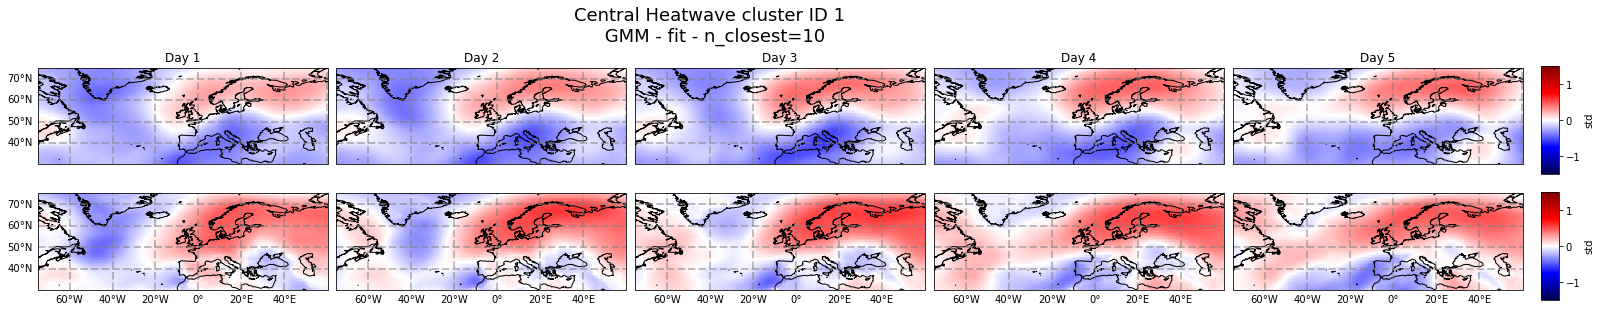

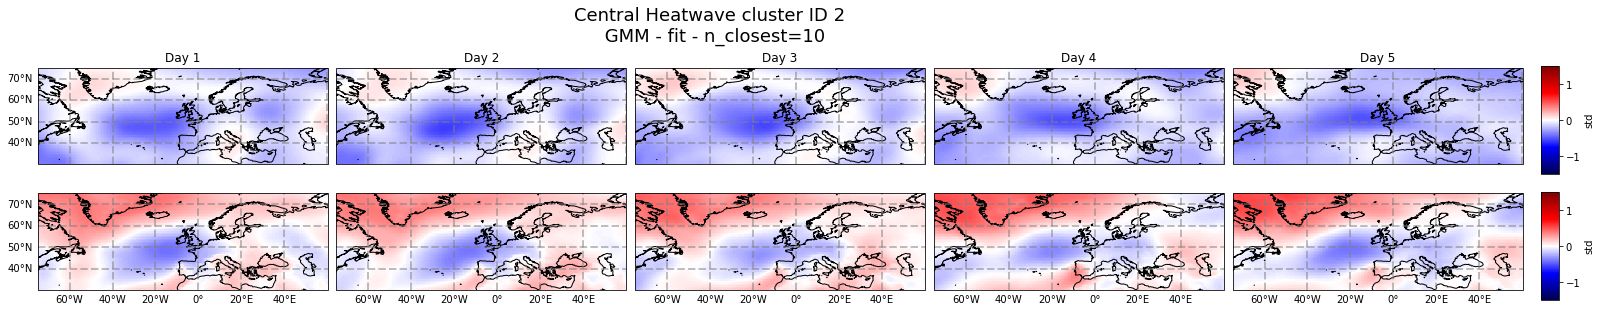

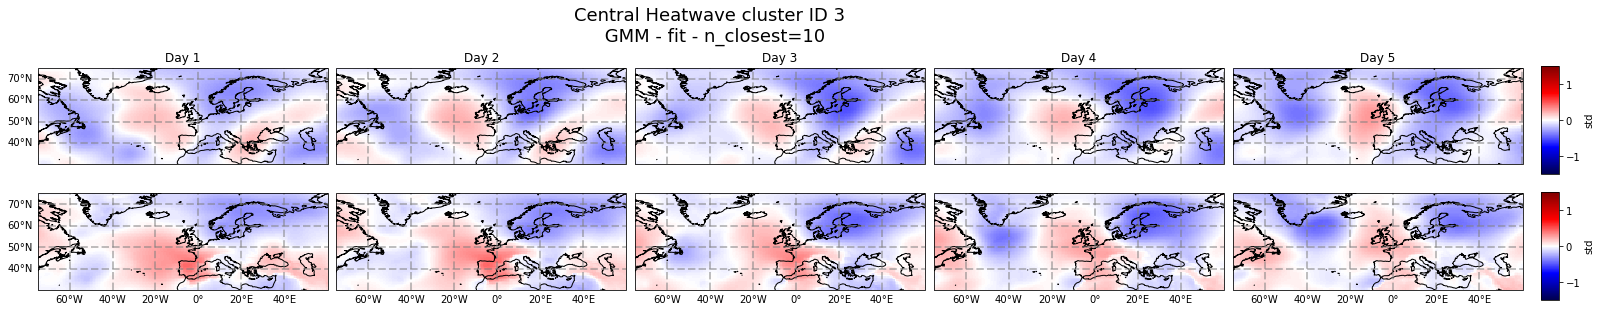

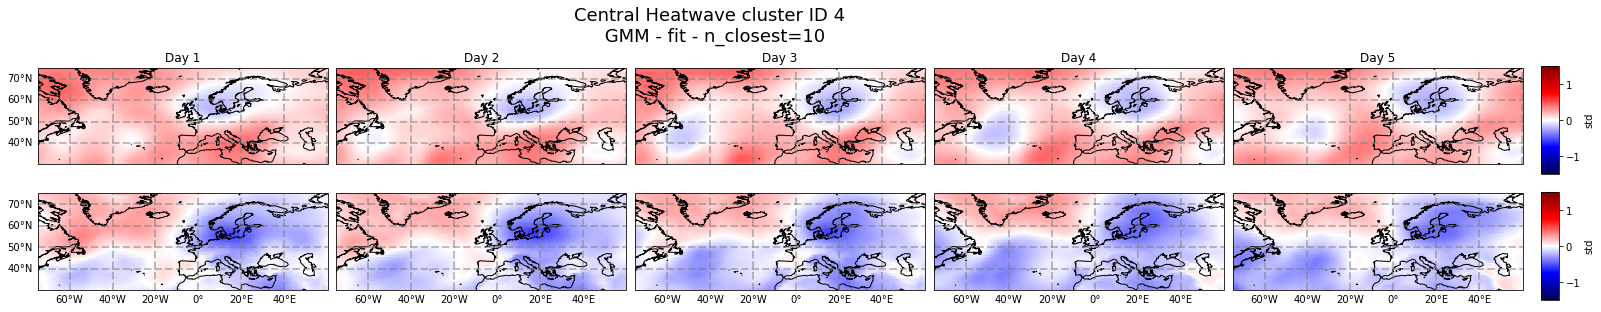

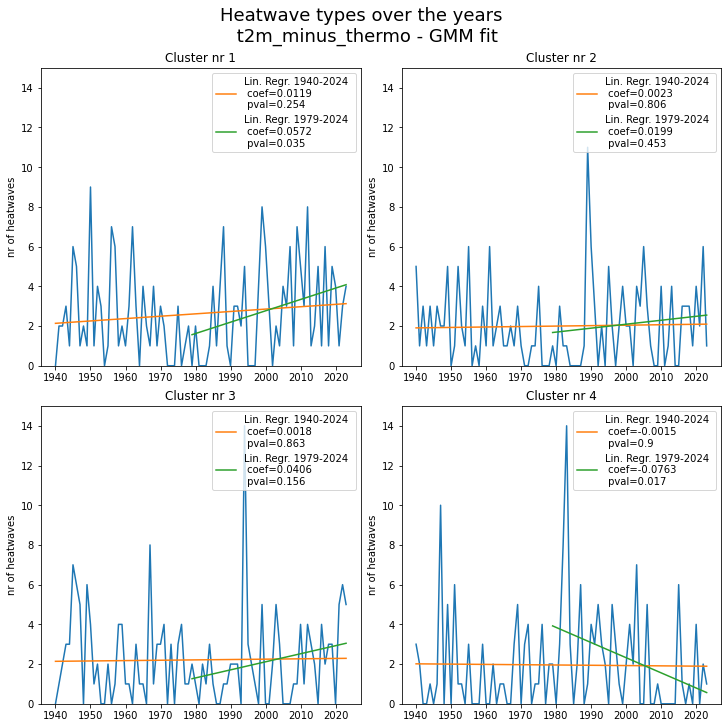

In [185]:
t2m_thermo_clustered.plot_central_heatwaves(n_closest=10)
t2m_thermo_clustered.plot_over_time_multiple()

## tsne

In [25]:
from openTSNE import TSNE


In [26]:
tsne = TSNE(
    perplexity=30,
    metric="euclidean",
    n_jobs=100,
    random_state=42,
    verbose=True,
)

In [29]:
both_collapsed.shape

(569, 128)

In [36]:
to_cluster = all_collapsed

%time embedding_train = tsne.fit(to_cluster)

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=100, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using exact search using euclidean distance...
   --> Time elapsed: 0.03 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.01 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.01 seconds
===> Running optimization with exaggeration=12.00, lr=61.58 for 250 iterations...
Iteration   50, KL divergence 1.0952, 50 iterations in 30.5124 sec
Iteration  100, KL divergence -1.5747, 50 iterations in 9.5826 sec
Iteration  150, KL divergence 2.9500, 50 iterations in 1.6452 sec
Iteration  200, KL divergence 2.9500, 50 iterations in 0.4102 sec
Iteration  250, KL divergence 2.9500, 50 iterations in 0.4108 sec
   --> Time elapsed: 42.56 seconds
===> Running optimization with exaggeration=1.00, lr=7

In [37]:
embedding_early = embedding_train.transform(np.array(heatwaves_1940_1970))
embedding_late = embedding_train.transform(np.array(heatwaves_1990_2020))

===> Finding 15 nearest neighbors in existing embedding using exact search...
   --> Time elapsed: 0.01 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=4.00, lr=0.10 for 0 iterations...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=1.50, lr=0.10 for 250 iterations...
Iteration   50, KL divergence 2343.2532, 50 iterations in 10.5188 sec
Iteration  100, KL divergence 2195.2106, 50 iterations in 10.0180 sec
Iteration  150, KL divergence 2163.2823, 50 iterations in 9.8428 sec
Iteration  200, KL divergence 2136.1537, 50 iterations in 9.7556 sec
Iteration  250, KL divergence 2125.0176, 50 iterations in 9.6977 sec
   --> Time elapsed: 49.83 seconds
===> Finding 15 nearest neighbors in existing embedding using exact search...
   --> Time elapsed: 0.01 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=4.00, lr=0.10 for 

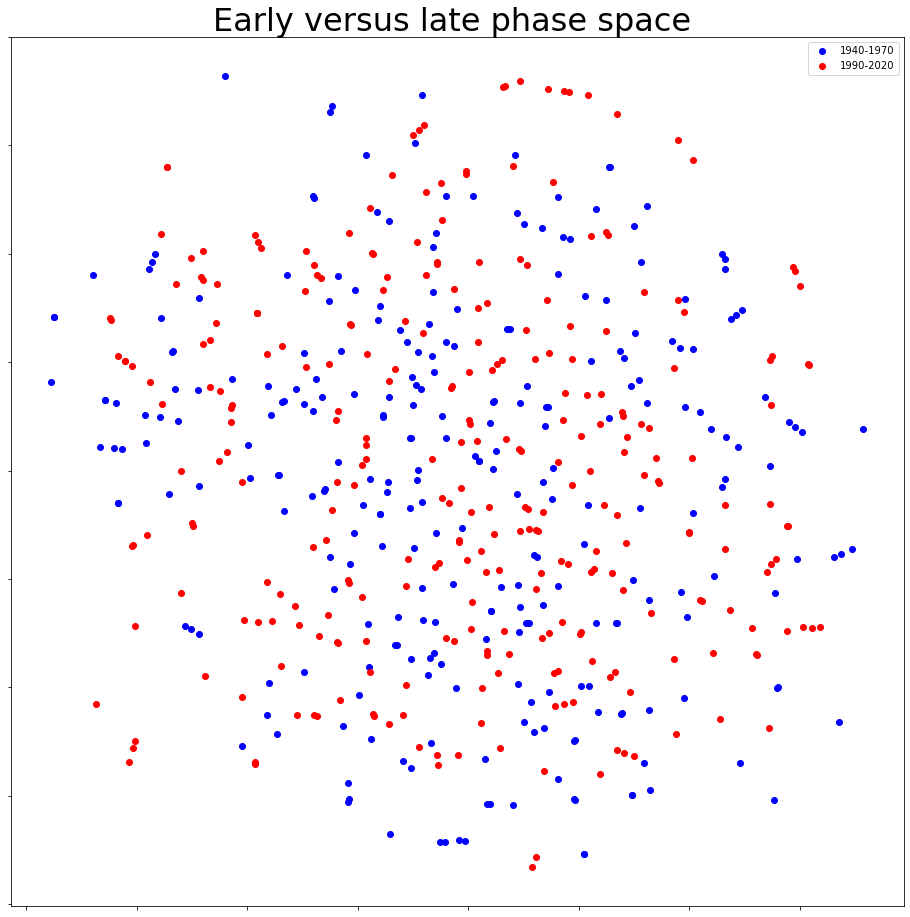

In [50]:
# plt.scatter(embedding_train[:,0], embedding_train[:,1],
#            color="black",
#            label="both")

    
plt.scatter(embedding_early[:,0], embedding_early[:,1],
           color="blue",
           label="1940-1970")

plt.scatter(embedding_late[:,0], embedding_late[:,1],
           color="red",
           label="1990-2020")


plt.tick_params(labelleft=False,labelbottom=False)    

plt.title("Early versus late phase space ", fontsize=32)
plt.legend()

plt.rcParams["figure.figsize"] = (16, 16)  # width=30 inches, height=6
plt.show()